# ==========================================================
# STUDENT MARKS PREDICTION USING Decision tree
# ==========================================================

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Import required libraries
import pandas as pd

# ==========================================================
# LOAD DATASET
# ==========================================================

# Read CSV file from Google Drive
file_path = "/content/drive/MyDrive/Colab Notebooks/Models Data/Student_Marks.csv"
df = pd.read_csv(file_path)

In [19]:
# X contains input features
# These are the values the model will use
# to make predictions
X = df[["number_courses", "time_study"]]

# y contains the target column
# This is what we want the model to predict
y = df["Marks"]

In [20]:
# ==========================================
# STEP 4: Split Data into Training and Testing
# ==========================================
from sklearn.model_selection import train_test_split

# Training Data:
# Used for teaching the model

# Testing Data:
# Used for checking how well the model learned
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
# ==========================================
# STEP 5: Create Decision Tree Model
# ==========================================
from sklearn.tree import DecisionTreeRegressor

# Create an instance of DecisionTreeRegressor

# Decision Tree Regressor is used when
# the output is a numerical value
model = DecisionTreeRegressor(random_state=42)

In [22]:
# ==========================================
# STEP 6: Train the Model
# ==========================================

# fit() teaches the model using
# training features and training targets
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [23]:
# ==========================================
# STEP 7: Make Predictions
# ==========================================

# Predict marks for unseen test data
y_pred = model.predict(X_test)
print(y_pred)

[17.264 35.939 16.703 10.844 10.844 53.018 13.416 51.583 43.978 17.672
 53.018 19.106  6.623 40.602 23.149 53.359 40.024 38.49  23.149 10.844
 15.725 13.416 12.132 19.59  22.184 22.184  7.734  6.185 31.236 21.379]


In [24]:
# ==========================================
# STEP 8: Compare Actual vs Predicted Values
# ==========================================
results = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})
print(results)

    Actual  Predicted
83  16.106     17.264
53  36.653     35.939
70  16.606     16.703
45   8.924     10.844
44   9.742     10.844
39  51.142     53.018
22  12.209     13.416
80  54.321     51.583
10  42.036     43.978
0   19.202     17.672
18  50.986     53.018
30  24.172     19.106
73   7.014      6.623
33  39.965     40.602
90  24.394     23.149
4   55.299     53.359
76  36.746     40.024
77  38.278     38.490
12  24.318     23.149
31   8.100     10.844
55  18.238     15.725
88  11.253     13.416
26  12.647     12.132
42  19.771     19.590
69  21.400     22.184
15  19.466     22.184
40   7.336      7.734
96   5.609      6.185
9   30.862     31.236
72  20.398     21.379


In [25]:
# ==========================================
# STEP 9: Evaluate Model Performance
# ==========================================
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Mean Absolute Error
# Average prediction error
mae = mean_absolute_error(y_test, y_pred)
# Mean Squared Error
# Squares errors before averaging
# Penalizes larger mistakes
mse = mean_squared_error(y_test, y_pred)
# R² Score
# Measures how much variance
# the model can explain
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

MAE : 1.4733666666666667
MSE : 3.3861468999999995
R2  : 0.9849495229626132


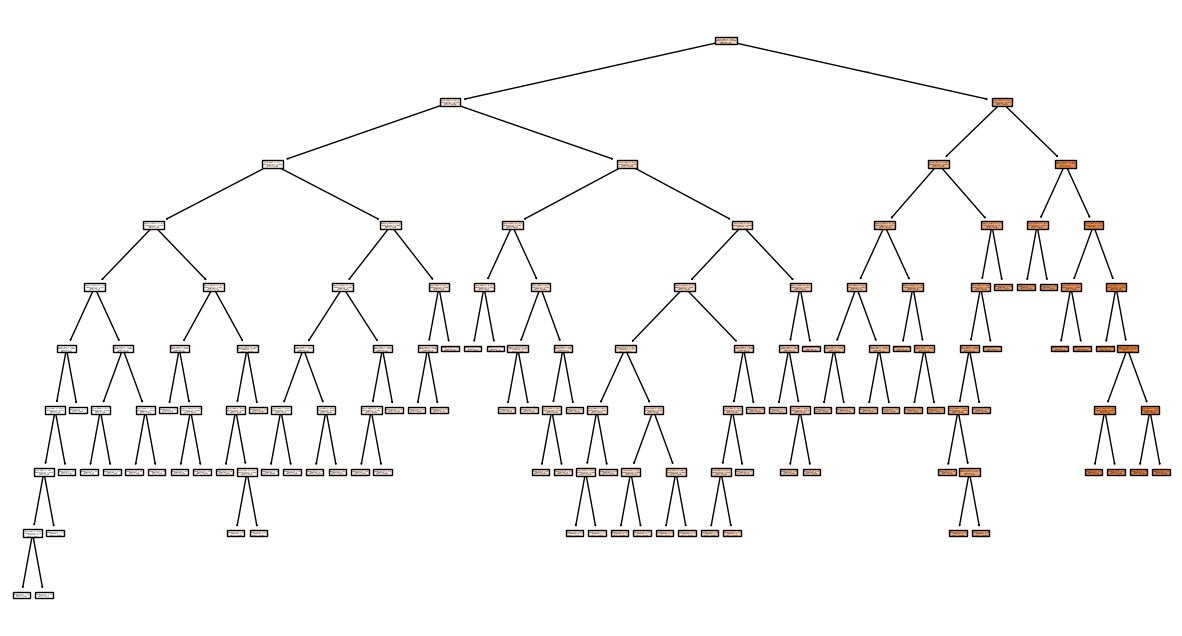

In [26]:
# ==========================================
# STEP 11: Visualize the Decision Tree
# ==========================================

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(model,feature_names=X.columns,filled=True)
plt.show()

In [27]:
# ==========================================
# STEP 12: Predict Marks for New Student
# ==========================================

# Example Student:
# number_courses = 5
# time_study = 6
new_student = [[5, 6]]

prediction = model.predict(new_student)
print("Predicted Marks:", prediction[0])

Predicted Marks: 29.889


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [28]:
# ==========================================
# STEP 10: Analyze Tree Complexity
# ==========================================

# Depth tells how many levels
# the tree has learned
print("Tree Depth:", model.get_depth())
# Number of final prediction nodes
print("Leaf Nodes:", model.get_n_leaves())

Tree Depth: 9
Leaf Nodes: 70
